# **INTRODUCTION**
[Action Against Hunger](https://www.actionagainsthunger.org.uk/our-impact/stories/the-hungriest-countries-in-the-world), ranks Nigeria as one of the world's hungriest countries. Additionally, [UNICEF](https://www.unicef.org/press-releases/25-million-nigerians-high-risk-food-insecurity-2023),
25 million Nigerians are at high risk of food insecurity in 2023. High food insecurity is caused by factors such as high rate of food infaltion, climate changes, high rates of poverty and unemployment.

Rising food prices affects the livelihood of Nigerian citizens, directly impacting economic stability and well-being. This project aims to utilize Data science and Machine Learning (ML) techniques to analyze historical food price data in Nigeria, predict future price trends, and provide valuable insights for the benefit of consumers, policymakers, and relevant stakeholders.


---

---





**PROJECT BREAKDOWN**
The project is broken down into 5 stages which include:


*   Data Collection and Preprocessing
*   Exploratory Data Analysis (EDA)
*   Feature Engineering
*   Model Development & Evaluation
*   Interactive Web Application

# **DATA COLLECTION AND PREPROCESSING**

**Importing the Neccessary Libraries**

In [65]:
#pip install streamlit

In [1]:
import pandas as pd
import numpy as np
import datetime
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
import requests
import re


# Sklearn tools
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate, KFold, GridSearchCV
from sklearn.preprocessing import MaxAbsScaler, OneHotEncoder, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from xgboost import XGBRegressor
#import streamlit as st

pd.set_option("display.max_columns", None)

ModuleNotFoundError: No module named 'pandas'

## 1. We imported the datasets in this section

In [67]:
#Rainfall dataset
data1 = pd.read_csv("rain.csv")

In [4]:
data1.head()

,State,City,Latitude,Longitude,Onset date,Season end,Date,Season Length Days,Annual Rainfall mm
0,Abia,Aba,5.10,7.35,8-Mar-2017,12-Dec-2017,2017,276,2505
1,Abia,Abiriba,5.70,7.73,15-Mar-2017,7-Dec-2017,2017,263,2220
2,Abia,Arochukwu,5.38,7.92,11-Mar-2017,10-Dec-2017,2017,270,2369
3,Abia,Arochukwu,5.53,7.76,13-Mar-2019,12-Dec-2019,2019,275,2201
4,Abia,Bende,5.55,7.63,14-Mar-2017,8-Dec-2017,2017,266,2289


In [5]:
#Food price dataset
data2 = pd.read_csv("all.csv")

In [6]:
#inflation rate dataset
data3 = pd.read_csv("InflationRates2019.csv")

## 2. Here we try to fish issues and clean them up

Since we will need to merged the dataset, we have to make sure there are some allignment between them.

>1. First we have make sure the years tally. To do this, we removed 2021 and 2022 from the food price dataset (data2)

>2. We have to make sure the states in each datasets tally. To do this, we use the assert method to check if the list of states in each data set (data1 and data2) are thesame

>3. We have to ...

In [7]:
#removing 2021 and 2022
data2 = data2[~data2['Date'].str.startswith(('2021', '2022'))]

In [8]:
#assert list(data1["State"].unique()) == list(data2["states"].unique())

In [9]:
data1.State.unique()

array(['Abia', 'Adamawa', 'Akwa Ibom', 'Anambra', 'Bauchi', 'Bayelsa',
       'Benue', 'Borno', 'Cross River', 'Delta', 'Ebonyi', 'Edo', 'Ekiti',
       'Enugu', 'Gombe', 'Imo', 'Jigawa', 'Kaduna', 'Kano', 'Katsina',
       'Kebbi', 'Kogi', 'Kwara', 'Lagos', 'Nasarawa', 'Niger', 'Ogun',
       'Ondo', 'Osun', 'Oyo', 'Plateau', 'Rivers', 'Sokoto', 'Taraba',
       'Yobe', 'Zamfara', 'FCT', 'River'], dtype=object)

In [10]:
data2.states.unique()

array(['Benue', 'Borno', 'Cross River', 'Delta', 'Ebonyi', 'Edo', 'Ekiti',
       'Enugu', 'Gombe', 'Imo', 'Jigawa', 'Kaduna', 'Kano', 'Katsina',
       'Kebbi', 'Kogi', 'Kwara', 'Lagos', 'Nassarawa', 'Niger', 'Ogun',
       'Ondo', 'Osun', 'Oyo', 'Plateau', 'Rivers', 'Sokoto', 'Taraba',
       'Yobe', 'Zamfara', 'Bayelsa', 'Bauchi', 'Anambra', 'Akwa Ibom',
       'Adamawa', 'Abia', 'Abuja'], dtype=object)

We notices some discrepancy in the spelling of 3 states (`Nasarawa`, `FCT` and `River`)

In [11]:
#data1["State"] = data1["State"].str.replace("FCT", "Abuja")
data1.loc[data1['State']== "FCT", "State"] = "Abuja"
data1.loc[data1['State']== "River", "State"] = "Rivers"
data1.loc[data1['State']== "Nasarawa", "State"] = "Nassarawa"

We corrected the errors/discrepancy, sorted the state columns for the two datasets and assert their similiarity.

In [12]:
data1 = data1.sort_values(by='State')

In [13]:
data2 = data2.sort_values(by='states')


In [14]:
assert list(data1["State"].unique()) == list(data2["states"].unique())

### Now lets scrape some data from the internet

In [15]:
urls = ["https://geokeo.com/database/state/ng/1/", "https://geokeo.com/database/state/ng/2/"]
dfs = pd.DataFrame()

for url in urls:
    pages = requests.get(url)
    soups = BeautifulSoup(pages.text, 'html')

    tables  = soups.find_all('table', class_ = "table table-hover table-bordered")[0]
    heading = tables.find('tr')
    title = [x.text.strip() for x in heading]
    result_list = [element for element in title if element != '']


    col_datas = tables.find_all('tr')
    data_rows = []
    for col in col_datas[1:]:
        row_datas = col.find_all('td')
        entrys = [data.text for data in row_datas]
        data_rows.append(entrys)

    page_df = pd.DataFrame(data_rows, columns=result_list)
    dfs = pd.concat([dfs, page_df], ignore_index=True)



In [16]:
# Some cleanings

#result_df['Name'] = result_df['States'].str.replace(r'\(\d+\)', '')
#df['States'] = df['States'].str.strip()

dfs.loc[dfs['Name']== "Federal Capital Territory", "Name"] = "Abuja"

dfs= dfs.rename(columns = {"Name":"State"})

df1 = dfs.drop(columns = ["#","Country", "Other Language Names"])

In [17]:
df1.head()
df1.to_csv("./long_lat_state.csv", index=False)

In [18]:
df = pd.read_csv("long_lat_state.csv")

In [19]:
df.head()

,State,Latitude,Longitude
0,Abia,5.454095,7.515307
1,Adamawa,9.512977,12.388189
2,Akwa Ibom,4.940864,7.841227
3,Anambra,6.218314,6.953184
4,Bauchi,10.622828,10.028775


### Next we want to limit the rainfall dataset (data1) such that only the states are used and not the local goverment.

In [20]:
food_df = data1.copy()

In [21]:
food_df = food_df[["State", "Date", "Season Length Days", "Annual Rainfall mm"]]

In [22]:
mean_df = food_df.pivot_table(index=['State', 'Date'],
                             values=['Season Length Days', 'Annual Rainfall mm'], aggfunc='mean')

In [23]:
mean_df =mean_df.reset_index()

In [24]:
mean_df["Date"].unique()

array([2017, 2019, 2020])

In [25]:
mean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   State               111 non-null    object 
 1   Date                111 non-null    int64  
 2   Annual Rainfall mm  111 non-null    float64
 3   Season Length Days  111 non-null    float64
dtypes: float64(2), int64(1), object(1)
memory usage: 3.6+ KB


We observed that 2018 is missing in this data. luckily we were able to download it from the site [Statista](https://www.statista.com/statistics/1264326/annual-rainfall-in-nigeria-by-state/)

In [26]:
seasonal_2018_interpolation = food_df.pivot_table(index=['State'],
                             values=['Season Length Days'], aggfunc='mean')
inte_df = seasonal_2018_interpolation.reset_index()


# We need just the seasonal length days

inte_list = inte_df[["Season Length Days"]]


In [27]:
# read in the dataset for 2018 rainfall
df_2018 = pd.read_excel("annual_rainfall_2018.xlsx", sheet_name = "data2")

df_2018["Season Length Days"] = inte_list

In [28]:
#df_2018["Date"] = pd.to_datetime(df_2018['Date'], format='%Y')
#df_2018["Date"] = df_2018["Date"].dt.year

df_2018.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                36 non-null     int64  
 1   State               36 non-null     object 
 2   Annual Rainfall mm  36 non-null     int64  
 3   Season Length Days  36 non-null     float64
dtypes: float64(1), int64(2), object(1)
memory usage: 1.2+ KB


In [29]:
new_df = mean_df.merge(df_2018, on=['Date', 'State', 'Annual Rainfall mm', 'Season Length Days'], how='outer', )

/var/folders/_9/z4llrcqd0y122r7_nwdcm5900000gn/T/ipykernel_962/1337846014.py:1: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  new_df = mean_df.merge(df_2018, on=['Date', 'State', 'Annual Rainfall mm', 'Season Length Days'], how='outer', )


In [30]:
new_df.isna().sum()

State                 0
Date                  0
Annual Rainfall mm    0
Season Length Days    0
dtype: int64

In [31]:
new_df.State.unique()

array(['Abia', 'Abuja', 'Adamawa', 'Akwa Ibom', 'Anambra', 'Bauchi',
       'Bayelsa', 'Benue', 'Borno', 'Cross River', 'Delta', 'Ebonyi',
       'Edo', 'Ekiti', 'Enugu', 'Gombe', 'Imo', 'Jigawa', 'Kaduna',
       'Kano', 'Katsina', 'Kebbi', 'Kogi', 'Kwara', 'Lagos', 'Nassarawa',
       'Niger', 'Ogun', 'Ondo', 'Osun', 'Oyo', 'Plateau', 'Rivers',
       'Sokoto', 'Taraba', 'Yobe', 'Zamfara', 'FCT', 'Nasarawa'],
      dtype=object)

In [32]:
df

,State,Latitude,Longitude
0,Abia,5.454095,7.515307
1,Adamawa,9.512977,12.388189
2,Akwa Ibom,4.940864,7.841227
3,Anambra,6.218314,6.953184
4,Bauchi,10.622828,10.028775
5,Bayelsa,4.762979,6.028898
6,Benue,7.350575,8.777288
7,Borno,12.187539,13.308003
8,Cross River,5.867197,8.520477
9,Delta,5.527306,6.178417


In [33]:
final_df = new_df.merge(df, on=['State'])

In [34]:
final_df

,State,Date,Annual Rainfall mm,Season Length Days,Latitude,Longitude
0,Abia,2017,2344.193548,269.193548,5.454095,7.515307
1,Abia,2019,2176.058824,273.529412,5.454095,7.515307
2,Abia,2020,2127.294118,276.764706,5.454095,7.515307
3,Abia,2018,2439.000000,272.307692,5.454095,7.515307
4,Abuja,2017,1136.117647,200.000000,8.831123,7.172467
...,...,...,...,...,...,...
138,Zamfara,2017,791.533333,131.733333,12.007900,6.419143
139,Zamfara,2019,434.714286,125.714286,12.007900,6.419143
140,Zamfara,2020,707.285714,131.142857,12.007900,6.419143
141,Zamfara,2018,891.000000,121.955556,12.007900,6.419143


In [35]:
data3["year"] =data3.index

In [36]:
data3.head()

,Year,Month,All Items (Year on Change),All Items (12 Months Avg. Change),Food (Year on Change)/1,Food (12 Months Avg. Change)/1,All Items Less Farm Produce (Year on Change)/2,All Items Less Farm Produce (12 Months Avg. Change)/2,All Items Less Farm Produce and Energy (Year on Change)/3,All Items Less Farm Produce and Energy (12 Months Avg. Change)/3,year
2003,1,10.6,12.3,7.5,11.6,16.1,13.4,13.6,8.6,NaN,2003
2003,2,7.3,11.4,3.5,9.7,14.2,14.3,12.1,8.9,NaN,2003
2003,3,5.9,10.5,0.1,7.9,15.4,15.0,13.9,9.4,NaN,2003
2003,4,8.3,10.1,3.3,6.9,16.9,15.6,17.6,10.4,NaN,2003
2003,5,8.7,10.0,3.3,6.3,17.6,16.3,15.5,11.3,NaN,2003


In [37]:
#inflation dataset
data3 = data3.rename(columns = {"Year":"Month", "Month":"All Items (Year on Change)",
                                "All Items (Year on Change)": "All Items (12 Months Avg. Change)",
                               "All Items (12 Months Avg. Change)": "Food (Year on Change)/1",
                                "Food (Year on Change)/1":"Food (12 Months Avg. Change)/1",
                                "Food (12 Months Avg. Change)/1": "All Items Less Farm Produce (Year on Change)/2",
                               "All Items Less Farm Produce (Year on Change)/2":"All Items Less Farm Produce (12 Months Avg. Change)/2",
                               "All Items Less Farm Produce (12 Months Avg. Change)/2":"All Items Less Farm Produce and Energy (Year on Change)/3"})

In [38]:
#selecting only required columns
data4 = data3[["Month","All Items (Year on Change)", "All Items (12 Months Avg. Change)",
              "Food (Year on Change)/1", "Food (12 Months Avg. Change)/1"]]
data5 = data4.reset_index()
data5 = data5.rename(columns = {"index":"Year"})

In [39]:
#Extracting 2017 to 2020 only
data6 = data5.loc[(data5["Year"]>=2017) & (data5["Year"]<=2020)]
data6 = data6.reset_index()
data6 =data6.drop(columns = ["index"])

In [40]:
#splitting the date column into year and month in the food price dataset
data2['Year'] = data2['Date'].str.extract(r'(\d{4})')
data2['Month'] = data2['Date'].str.extract(r'M(\d+)')

In [41]:
#Dropping irrelevant columns from the food price dataset
data7= data2.copy()
data7 = data7.drop(columns = ["Date", "Unit"])

In [42]:
#converting year and month into integer in the foodprice dataset
data7["Year"] = data7["Year"].astype(int)
data7["Month"] = data7["Month"].astype(int)

In [43]:
data7

,states,crops,Value,Year,Month
29988,Abia,Onion bulb,231.095570,2018,12
30122,Abia,Maize grain yellow sold loose,258.950617,2019,4
30123,Abia,Maize grain yellow sold loose,244.631154,2019,5
30124,Abia,Maize grain yellow sold loose,168.518519,2019,6
30125,Abia,Maize grain yellow sold loose,137.847222,2019,7
...,...,...,...,...,...
24783,Zamfara,Tomato,320.418572,2018,7
24784,Zamfara,Tomato,341.850253,2018,8
24785,Zamfara,Tomato,357.238564,2018,9
24778,Zamfara,Tomato,248.330897,2018,2


In [44]:
#First merging:merging the food price dataset with the inflation data
merged_df = data7.merge(data5, on=['Year', 'Month'])

In [45]:
#Sort the merged data by state Alphabetically
merged_df = merged_df.sort_values(by='states')
merged_df.states.unique()

array(['Abia', 'Abuja', 'Adamawa', 'Akwa Ibom', 'Anambra', 'Bauchi',
       'Bayelsa', 'Benue', 'Borno', 'Cross River', 'Delta', 'Ebonyi',
       'Edo', 'Ekiti', 'Enugu', 'Gombe', 'Imo', 'Jigawa', 'Kaduna',
       'Kano', 'Katsina', 'Kebbi', 'Kogi', 'Kwara', 'Lagos', 'Nassarawa',
       'Niger', 'Ogun', 'Ondo', 'Osun', 'Oyo', 'Plateau', 'Rivers',
       'Sokoto', 'Taraba', 'Yobe', 'Zamfara'], dtype=object)

In [46]:
#Quick renaming of the state and the date columns of rainfall data
data = final_df.rename(columns= {"State": "states", "Date":"Year"})

data.loc[data['states']== "Nasarawa", "states"] = "Nassarawa"
data.states.unique()

array(['Abia', 'Abuja', 'Adamawa', 'Akwa Ibom', 'Anambra', 'Bauchi',
       'Bayelsa', 'Benue', 'Borno', 'Cross River', 'Delta', 'Ebonyi',
       'Edo', 'Ekiti', 'Enugu', 'Gombe', 'Imo', 'Jigawa', 'Kaduna',
       'Kano', 'Katsina', 'Kebbi', 'Kogi', 'Kwara', 'Lagos', 'Niger',
       'Ogun', 'Ondo', 'Osun', 'Oyo', 'Plateau', 'Rivers', 'Sokoto',
       'Taraba', 'Yobe', 'Zamfara', 'Nassarawa'], dtype=object)

In [47]:
#Second merging: merging the first merged dataset with rainfall dataset
merged_df2 = data.merge(merged_df, on=['states', 'Year'])

merged_df2.head()

,states,Year,Annual Rainfall mm,Season Length Days,Latitude,Longitude,crops,Value,Month,All Items (Year on Change),All Items (12 Months Avg. Change),Food (Year on Change)/1,Food (12 Months Avg. Change)/1
0,Abia,2017,2344.193548,269.193548,5.454095,7.515307,"Beans brown,sold loose",458.333333,7,16.05,17.47,20.28,18.25
1,Abia,2017,2344.193548,269.193548,5.454095,7.515307,Rice Medium Grained,439.665224,7,16.05,17.47,20.28,18.25
2,Abia,2017,2344.193548,269.193548,5.454095,7.515307,"Gari white,sold loose",394.147465,7,16.05,17.47,20.28,18.25
3,Abia,2017,2344.193548,269.193548,5.454095,7.515307,Beans:white black eye. sold loose,463.793103,7,16.05,17.47,20.28,18.25
4,Abia,2017,2344.193548,269.193548,5.454095,7.515307,"Gari yellow,sold loose",428.156682,7,16.05,17.47,20.28,18.25


In [48]:
#Tidying up and renaming the columns
merged_df3 = merged_df2.rename(columns =
                               {"Value":"Price/Kg(Naira)", "All Items (Year on Change)":"Annual_all_item_inflation",
                             "All Items (12 Months Avg. Change)":"Monthly_all_item_inflation",
                             "Food (Year on Change)/1":"Annual_food_inflation",
                                "Food (12 Months Avg. Change)/1": "Monthly_food_inflation",
                               "Annual Rainfall mm": "Annual_rainfall_mm", 
                                "Season Length Days": "Seasonal_length_days"})


In [49]:
merged_df3.head()

,states,Year,Annual_rainfall_mm,Seasonal_length_days,Latitude,Longitude,crops,Price/Kg(Naira),Month,Annual_all_item_inflation,Monthly_all_item_inflation,Annual_food_inflation,Monthly_food_inflation
0,Abia,2017,2344.193548,269.193548,5.454095,7.515307,"Beans brown,sold loose",458.333333,7,16.05,17.47,20.28,18.25
1,Abia,2017,2344.193548,269.193548,5.454095,7.515307,Rice Medium Grained,439.665224,7,16.05,17.47,20.28,18.25
2,Abia,2017,2344.193548,269.193548,5.454095,7.515307,"Gari white,sold loose",394.147465,7,16.05,17.47,20.28,18.25
3,Abia,2017,2344.193548,269.193548,5.454095,7.515307,Beans:white black eye. sold loose,463.793103,7,16.05,17.47,20.28,18.25
4,Abia,2017,2344.193548,269.193548,5.454095,7.515307,"Gari yellow,sold loose",428.156682,7,16.05,17.47,20.28,18.25


In [50]:
merged_df3.to_csv("./food_price_dataset.csv", index = False)

In [51]:
price_df = pd.read_csv("food_price_dataset.csv")

# Lets explore the new datasets

In [52]:
# Exploring the first few columns
price_df.head()

,states,Year,Annual_rainfall_mm,Seasonal_length_days,Latitude,Longitude,crops,Price/Kg(Naira),Month,Annual_all_item_inflation,Monthly_all_item_inflation,Annual_food_inflation,Monthly_food_inflation
0,Abia,2017,2344.193548,269.193548,5.454095,7.515307,"Beans brown,sold loose",458.333333,7,16.05,17.47,20.28,18.25
1,Abia,2017,2344.193548,269.193548,5.454095,7.515307,Rice Medium Grained,439.665224,7,16.05,17.47,20.28,18.25
2,Abia,2017,2344.193548,269.193548,5.454095,7.515307,"Gari white,sold loose",394.147465,7,16.05,17.47,20.28,18.25
3,Abia,2017,2344.193548,269.193548,5.454095,7.515307,Beans:white black eye. sold loose,463.793103,7,16.05,17.47,20.28,18.25
4,Abia,2017,2344.193548,269.193548,5.454095,7.515307,"Gari yellow,sold loose",428.156682,7,16.05,17.47,20.28,18.25


In [53]:
# Checking out the columns and enteries as well as data types
price_df.crops.unique()

array(['Beans brown,sold loose', 'Rice Medium Grained',
       'Gari white,sold loose', 'Beans:white black eye. sold loose',
       'Gari yellow,sold loose', 'Onion bulb', 'Broken Rice (Ofada)',
       'Tomato', 'Plantain(unripe)', 'Maize grain white sold loose',
       'Yam tuber', 'Maize grain yellow sold loose', 'Plantain(ripe)'],
      dtype=object)

In [54]:
#Exploring some statistical summaries of the columns
price_df.describe()

,Year,Annual_rainfall_mm,Seasonal_length_days,Latitude,Longitude,Price/Kg(Naira),Month,Annual_all_item_inflation,Monthly_all_item_inflation,Annual_food_inflation,Monthly_food_inflation
count,22308.000000,22308.000000,22308.000000,22308.000000,22308.000000,22308.000000,22308.00000,22308.000000,22308.000000,22308.000000,22308.000000
mean,2018.503497,1376.182503,208.217108,8.479331,7.377520,265.266017,6.50000,13.331777,13.702995,15.960350,15.850851
std,1.121177,619.009292,53.790912,2.529440,2.483499,103.208462,3.45213,2.212775,2.361964,2.586809,2.129741
min,2017.000000,314.000000,109.478261,4.762979,3.438929,70.356125,1.00000,11.020000,11.270000,12.850000,13.340000
25%,2017.000000,801.250000,161.636364,6.218314,5.315220,195.711710,3.75000,11.370000,11.540000,13.510000,13.860000
50%,2019.000000,1309.000000,223.625000,8.014133,7.172467,249.234658,6.50000,12.400000,12.660000,15.030000,15.360000
75%,2020.000000,1851.190476,253.700000,10.622828,8.777288,322.592843,9.25000,15.750000,16.440000,18.530000,17.750000
max,2020.000000,2695.100000,288.130435,13.061119,13.308003,985.075365,12.00000,18.720000,17.630000,20.320000,19.620000


In [55]:
#Checking out and dropping duplicated values
price_df.duplicated().sum()
#price_df = price_df.drop_duplicates()

0

In [56]:
#There are no missing values
price_df.isnull().sum()

states                        0
Year                          0
Annual_rainfall_mm            0
Seasonal_length_days          0
Latitude                      0
Longitude                     0
crops                         0
Price/Kg(Naira)               0
Month                         0
Annual_all_item_inflation     0
Monthly_all_item_inflation    0
Annual_food_inflation         0
Monthly_food_inflation        0
dtype: int64

# Creating a new column called month name
def map_month(month_num):
    month_names = {1: 'Jan', 2: 'Feb', 3: 'March', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul',
                  8: 'Aug', 9: 'Sept', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
    return month_names.get(month_num, 'Invalid Month')

# Create a new column with month names
price_df['Month Name'] = price_df['Month'].apply(lambda x: map_month(x))

In [57]:
price_df['Year'] = price_df.Year.astype(str)

In [58]:
#Checking the final shape of the dataset
price_df.shape

(22308, 13)

# Let's commence visualization

In [59]:
# Checking the number of unique values for the crops

uniques = price_df.crops.unique()
for i, x in enumerate(uniques):
    print(f"{i} -------  {x}")

0 -------  Beans brown,sold loose
1 -------  Rice Medium Grained
2 -------  Gari white,sold loose
3 -------  Beans:white black eye. sold loose
4 -------  Gari yellow,sold loose
5 -------  Onion bulb
6 -------  Broken Rice (Ofada)
7 -------  Tomato
8 -------  Plantain(unripe)
9 -------  Maize grain white sold loose
10 -------  Yam tuber
11 -------  Maize grain yellow sold loose
12 -------  Plantain(ripe)


In [60]:
# Lets check the rainfall distribution


fig = px.histogram(price_df["Annual_rainfall_mm"],
                   nbins=40, title='Annual_rainfall_distribution',
                   labels={'x': 'Rainfall', 'y': 'Frequency'})
fig.show()

In [61]:
price_df.head()

,states,Year,Annual_rainfall_mm,Seasonal_length_days,Latitude,Longitude,crops,Price/Kg(Naira),Month,Annual_all_item_inflation,Monthly_all_item_inflation,Annual_food_inflation,Monthly_food_inflation
0,Abia,2017,2344.193548,269.193548,5.454095,7.515307,"Beans brown,sold loose",458.333333,7,16.05,17.47,20.28,18.25
1,Abia,2017,2344.193548,269.193548,5.454095,7.515307,Rice Medium Grained,439.665224,7,16.05,17.47,20.28,18.25
2,Abia,2017,2344.193548,269.193548,5.454095,7.515307,"Gari white,sold loose",394.147465,7,16.05,17.47,20.28,18.25
3,Abia,2017,2344.193548,269.193548,5.454095,7.515307,Beans:white black eye. sold loose,463.793103,7,16.05,17.47,20.28,18.25
4,Abia,2017,2344.193548,269.193548,5.454095,7.515307,"Gari yellow,sold loose",428.156682,7,16.05,17.47,20.28,18.25


/Users/rabiat/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/Users/rabiat/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/var/folders/_9/z4llrcqd0y122r7_nwdcm5900000gn/T/ipykernel_962/1936150461.py:8: UserWarning:

FixedFormatter should only be used together with FixedLocator



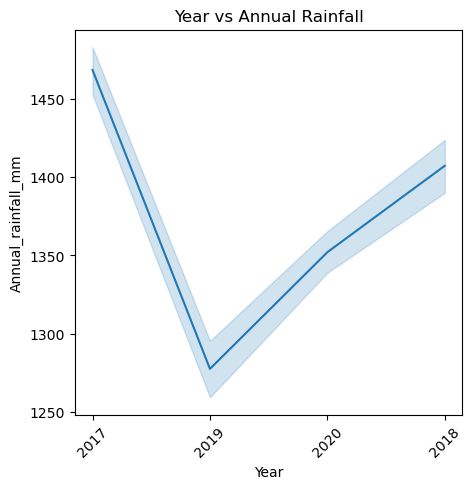

In [62]:
# Let us see the annual rainfall for each year

plt.figure(figsize=(5, 5))  # Adjust the figure size as needed
ax=sns.lineplot(data=price_df, x='Year', y='Annual_rainfall_mm')

# Set title
plt.title('Year vs Annual Rainfall')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
# Show the plot
plt.show()

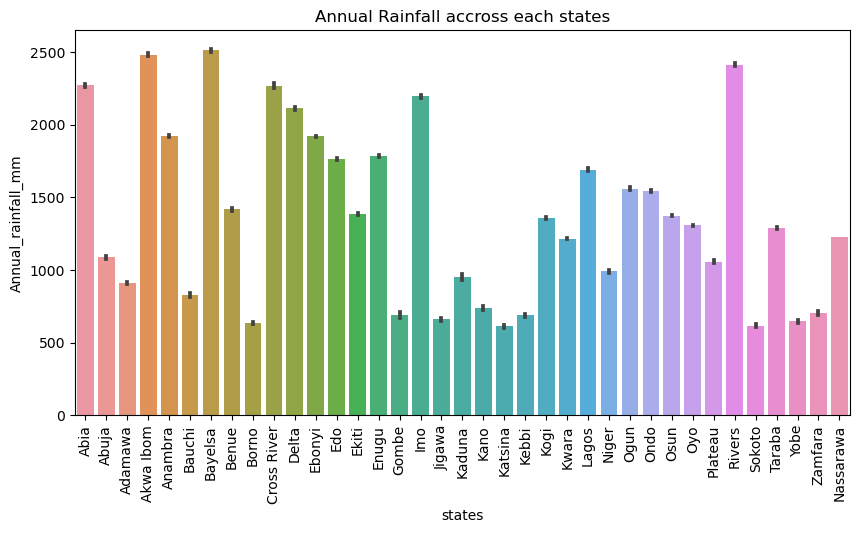

In [63]:
# Let us see the annual rainfall for each year


plt.figure(figsize=(10, 5))  # Adjust the figure size as needed
ax= sns.barplot(data=price_df, x='states', y='Annual_rainfall_mm')

# Set title
plt.title('Annual Rainfall accross each states')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

# Show the plot
plt.show()

In [64]:
price_df_2017= price_df[price_df["Year"]=="2017"]
price_df_20171= price_df_2017.sort_values(by = ["Annual Rainfall mm"])

price_df_2018= price_df[price_df["Year"]=="2018"]
price_df_20181= price_df_2018.sort_values(by = ["Annual_rainfall_mm"])

price_df_2019= price_df[price_df["Year"]=="2019"]
price_df_20191= price_df_2019.sort_values(by = ["Annual_rainfall_mmm"])


price_df_2020= price_df[price_df["Year"]=="2020"]
price_df_20201= price_df_2020.sort_values(by = ["Annual_rainfall_mm"])

KeyError: 'Annual Rainfall mm'

In [ ]:
#price_df_20181

In [ ]:

plt.figure(figsize=(10, 5))
ax1 = sns.lineplot(data=price_df_2017, x='states', y='Annual Rainfall mm', label="2017")
ax2 = sns.lineplot(data=price_df_2018, x='states', y='Annual Rainfall mm', label="2018")
ax3 = sns.lineplot(data=price_df_2019, x='states', y='Annual Rainfall mm', label="2019")
ax4 = sns.lineplot(data=price_df_2020, x='states', y='Annual Rainfall mm', label="2020")
plt.title('Annual Rainfall accross each states')
plt.legend()
ax1.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.show()

In [ ]:
price_df_yam= price_df[price_df["crops"]=="Yam tuber"]
plt.figure(figsize=(10, 5))
axe= sns.barplot(data=price_df_yam, x='states', y='Price/Kg (Naira)')
plt.title('Cost of Yam tuber per Kg accross the states (2017 to 2020)')
axe.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.xlabel('States')
plt.ylabel('Price in Naira/kg')
plt.show()

In [ ]:
price_df_rice= price_df[price_df["crops"]=="Rice Medium Grained"]
plt.figure(figsize=(10, 5))

gx = sns.barplot(data=price_df_rice, x='states', y='Price/Kg (Naira)')
gx.set_xticklabels(gx.get_xticklabels(), rotation=90)
plt.title('Cost of Rice per Kg accross the states (2017 to 2020)')
plt.xlabel('States')
plt.ylabel('Price in Naira/kg')
plt.show()

In [ ]:
price_df_Beans= price_df[price_df["crops"]=="Beans brown,sold loose"]
plt.figure(figsize=(10, 5))

gx = sns.barplot(data=price_df_Beans, x='states', y='Price/Kg (Naira)')
gx.set_xticklabels(gx.get_xticklabels(), rotation=90)
plt.title('Cost of Beans per Kg accross the states (2017 to 2020)')
plt.xlabel('States')
plt.ylabel('Price in Naira/kg')
plt.show()

In [ ]:
price_df_plantain= price_df[price_df["crops"]=="Plantain(ripe)"]
plt.figure(figsize=(10, 5))

gx = sns.barplot(data=price_df_plantain, x='states', y='Price/Kg (Naira)')
gx.set_xticklabels(gx.get_xticklabels(), rotation=90)
plt.title('Cost of Plantain per Kg accross the states (2017 to 2020)')
plt.xlabel('States')
plt.ylabel('Price in Naira/kg')
plt.show()

In [ ]:
price_df_garri= price_df[price_df["crops"]=="Gari white,sold loose"]
plt.figure(figsize=(10, 5))

gx = sns.barplot(data=price_df_garri, x='states', y='Price/Kg (Naira)')
gx.set_xticklabels(gx.get_xticklabels(), rotation=90)
plt.title('Cost of Garri per Kg accross the states (2017 to 2020)')
plt.xlabel('States')
plt.ylabel('Price in Naira/kg')
plt.show()

In [ ]:
price_df_maize= price_df[price_df["crops"]=="Maize grain white sold loose"]
plt.figure(figsize=(10, 5))

gx = sns.barplot(data=price_df_maize, x='states', y='Price/Kg (Naira)')
gx.set_xticklabels(gx.get_xticklabels(), rotation=90)
plt.title('Cost of Maize per Kg accross the states (2017 to 2020)')
plt.xlabel('States')
plt.ylabel('Price in Naira/kg')
plt.show()

In [ ]:
price_df_onions= price_df[price_df["crops"]=="Onion bulb"]
plt.figure(figsize=(10, 5))

gx = sns.barplot(data=price_df_onions, x='states', y='Price/Kg (Naira)')
gx.set_xticklabels(gx.get_xticklabels(), rotation=90)
plt.title('Cost of Onion bulb per Kg accross the states (2017 to 2020)')
plt.xlabel('States')
plt.ylabel('Price in Naira/kg')
plt.show()

In [ ]:
price_df_Tomato= price_df[price_df["crops"]=="Tomato"]
plt.figure(figsize=(10, 5))

gx = sns.barplot(data=price_df_Tomato, x='states', y='Price/Kg (Naira)')
gx.set_xticklabels(gx.get_xticklabels(), rotation=90)
plt.title('Cost of Tomato per Kg accross the states (2017 to 2020)')
plt.xlabel('States')
plt.ylabel('Price in Naira/kg')
plt.show()

In [ ]:
price_df_ofada= price_df[price_df["crops"]=="Broken Rice (Ofada)"]
plt.figure(figsize=(10, 5))

gx = sns.barplot(data=price_df_ofada, x='states', y='Price/Kg (Naira)')
gx.set_xticklabels(gx.get_xticklabels(), rotation=90)
plt.title('Cost of Broken Rice (Ofada) per Kg accross the states (2017 to 2020)')
plt.xlabel('States')
plt.ylabel('Price in Naira/kg')
plt.show()

In [ ]:
average_inflation_by_year_crop = price_df.groupby(['crops','Year'])['inflation_rate(all_item annual)'].mean().unstack()
average_inflation_by_year_crop

In [ ]:
#average price of food crop per year

average_price_by_year_crop = price_df.groupby(['crops','Year'])['Price/Kg (Naira)'].mean().unstack()
average_price_by_year_crop

In [ ]:
# Grouping 'crops' and 'Year' columns and calculating mean price per year for each crop
average_price_by_year_crop = price_df.groupby(['crops', 'Year'])['Price/Kg (Naira)'].mean().unstack()

#creating a plot
plt.figure(figsize=(12, 8))

for crop in average_price_by_year_crop.index:
    plt.plot(average_price_by_year_crop.columns, average_price_by_year_crop.loc[crop], label=crop)

plt.title('Average Price of Food Crops per Year')
plt.xlabel('Year')
plt.ylabel('Average Price (Naira per Kg)')
plt.legend(loc='best', bbox_to_anchor=(1.05, 1))


# Show plot
plt.show()

In [ ]:
plt.figure(figsize=(20, 10))

# Line plot for Annual Rainfall
plt.subplot(131)
sns.lineplot(x='states', y='Annual Rainfall mm', data=price_df)
plt.title('Annual Rainfall by State')
plt.xlabel('States')
plt.ylabel('Annual Rainfall (mm)')
plt.xticks(rotation= 90)


# Line plot for Season Length
plt.subplot(132)
sns.lineplot(x='states', y='Season Length Days', data=price_df)
plt.title('Season Length by State')
plt.xlabel('States')
plt.ylabel('Season Length (Days)')
plt.xticks(rotation= 90)

# Line plot for Price/Kg (Naira)
plt.subplot(133)
sns.lineplot(x='states', y='Price/Kg (Naira)', data=price_df)
plt.title('Price/Kg (Naira) by State')
plt.xlabel('States')
plt.ylabel('Price/Kg (Naira)')
plt.xticks(rotation= 90)

# Adjust layout and display the plot

plt.show()

In [ ]:
price_df.head()


# Heatmap:


In [ ]:
plt.figure(figsize=(10, 5))
correlation_matrix = price_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# BAR PLOT
Display trends in Inflation Rates over the months or years. Plot Crop Prices over the months to identify seasonal patterns.

In [ ]:

bar_width = 0.4  # Width of the bars
index = price_df['Month']  # Assuming 'Month' is a categorical variable

plt.bar(index, price_df['inflation_rate(all_item annual)'], width=bar_width, label='All Items')
plt.bar(index + bar_width, price_df['inflation_rate(food_item monthly avg.)'], width=bar_width, label='Food Items', linestyle='--')

plt.xlabel('Month')
plt.ylabel('Inflation Rate')
plt.title('Inflation Rates Over Months')
plt.legend()
plt.show()


# Box Plots:¶
Analyze the distribution of Crop Prices or Rainfall for each state. Explore the distribution of Inflation Rates.

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='crops', y='Price/Kg (Naira)', data=price_df)
plt.xlabel('states')
plt.ylabel('Price/Kg (Naira)')
plt.title('Distribution of Crop Prices for Each State')
plt.xticks(rotation=90)
plt.show()


# Model Development.

In [ ]:
Total_col= list(price_df.columns)
Total_col

['states',
 'Year',
 'Annual_rainfall_mm',
 'Seasonal_length_days',
 'Latitude',
 'Longitude',
 'crops',
 'Price/Kg(Naira)',
 'Month',
 'Annual_all_item_inflation',
 'Monthly_all_item_inflation',
 'Annual_food_inflation',
 'Monthly_food_inflation']

In [ ]:
num_cols = list(price_df.select_dtypes(exclude = 'object').columns)
num_cols

['Annual_rainfall_mm',
 'Seasonal_length_days',
 'Latitude',
 'Longitude',
 'Price/Kg(Naira)',
 'Month',
 'Annual_all_item_inflation',
 'Monthly_all_item_inflation',
 'Annual_food_inflation',
 'Monthly_food_inflation']

In [ ]:
# Extract the numeric columns
num_cols = list(price_df.select_dtypes(exclude = 'object').columns)
num_cols.pop(4)          # Remove the target variable
categorical_list= ['states','crops']

target = ['Price/Kg (Naira)']
drop = num_cols + target

In [ ]:
num_cols

['Annual_rainfall_mm',
 'Seasonal_length_days',
 'Latitude',
 'Longitude',
 'Month',
 'Annual_all_item_inflation',
 'Monthly_all_item_inflation',
 'Annual_food_inflation',
 'Monthly_food_inflation']

# Method 2: using one hot encoder

In [ ]:
df2 = price_df.copy()

In [ ]:
scaler = MinMaxScaler()

In [ ]:
df_con = df2[num_cols]
df_con.head()
scale_col = list(df_con.columns)

In [ ]:
df_scaled = scaler.fit_transform(df_con)
#df_scaled

In [ ]:
df_scaled_ = pd.DataFrame(df_scaled, columns=scale_col)

In [ ]:
encoder = OneHotEncoder(sparse = False, handle_unknown = 'ignore')

In [ ]:
encoder.fit(df2[categorical_list])

In [ ]:
encoded_cols = list(encoder.get_feature_names_out(categorical_list))


In [ ]:
df2[encoded_cols] = encoder.transform(df2[categorical_list])

In [ ]:
df2.head()

In [ ]:
df_final = pd.concat([df2[encoded_cols], df_scaled_], axis=1)
df_final.shape

In [ ]:
len(df2[target])

In [ ]:
x_train,x_test,ytrain,ytest = train_test_split(df_final, df2[target], test_size = 0.2,random_state = 42)

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(x_train, ytrain)

In [ ]:
ypred = model.predict(x_test)

In [ ]:
R2 = r2_score (ytest, ypred)
R2

In [ ]:
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)

In [ ]:
rf_regressor.fit(x_train, ytrain)

In [ ]:
y_pred = rf_regressor.predict(x_test)


In [ ]:
r2_score (ytest, y_pred)

# Building the pipeline

In [ ]:
df3= price_df.copy()
X=df3[num_cols + categorical_list]
y= df3[target]

In [ ]:
# Pipeline for numerical and categorical columns

num_pipe = Pipeline(steps=[("scale", MinMaxScaler())])
cat_pipe = Pipeline(steps=[("encoder", OneHotEncoder())])

#Performing transformation with the pipelines
column_transform = ColumnTransformer(transformers=[("num_trans", num_pipe, num_cols),
                                                  ("cat_trans", cat_pipe, categorical_list)],
                                     remainder="drop", n_jobs=-1)

# Defining oour model
RF_regressor = RandomForestRegressor(n_estimators=100, random_state=42)

# Final pipeline
pipeline = Pipeline(steps= [("transformation", column_transform),
                           ("model", RF_regressor)])
pipeline

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state=1)

pipeline.fit(X_train, y_train)

predicted = pipeline.predict(X_test)

In [ ]:
R2 = r2_score(y_test, predicted)

print(f"R2-score {R2}")


MSE = mean_squared_error(y_test, predicted, squared=False)
print(f"Mean squared error: {MSE}")

MAE = mean_absolute_error(y_test, predicted)
print(f"Mean absolute error: {MAE}")

# XGBoost

In [ ]:
xgb_regressor = XGBRegressor(learning_rate=0.1,
    n_estimators= 150,
    max_depth= 15)

xgb_pipeline = Pipeline(steps= [("transformation", column_transform),
                           ("model", xgb_regressor)])
xgb_pipeline

xgb_pipeline.fit(X_train, y_train)

predicted2 = xgb_pipeline.predict(X_test)

In [ ]:
R2 = r2_score(y_test, predicted2)
print(f"R2-score {R2}")


MSE = mean_squared_error(y_test, predicted2, squared=False)
print(f"Mean squared error: {MSE}")

MAE = mean_absolute_error(y_test, predicted2)
print(f"Mean absolute error: {MAE}")